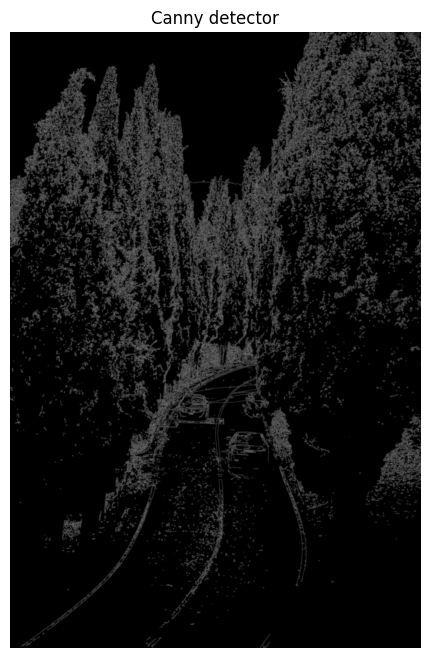

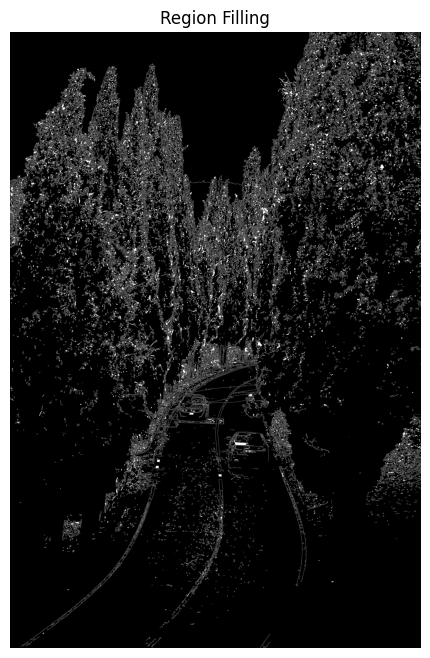

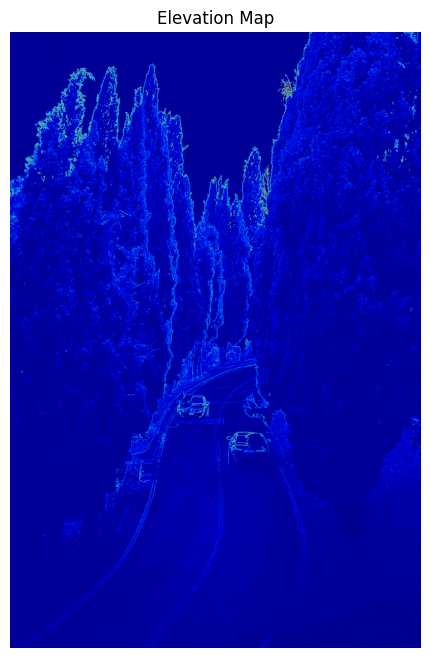

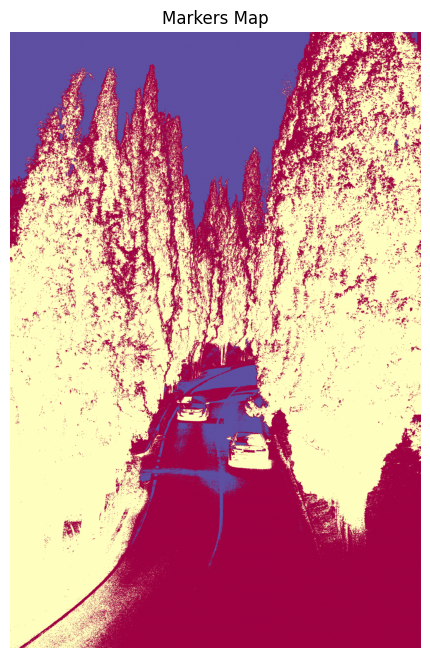

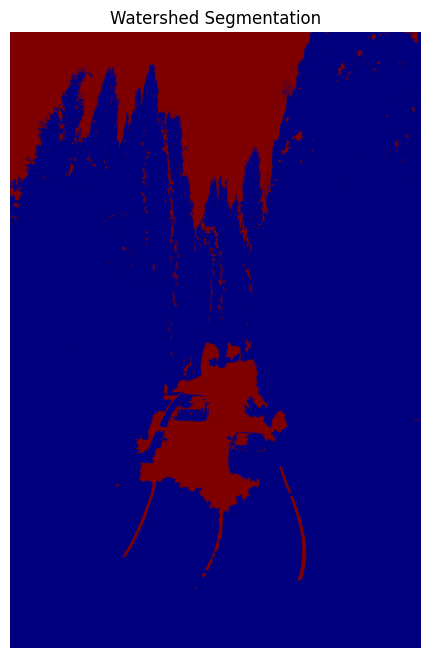

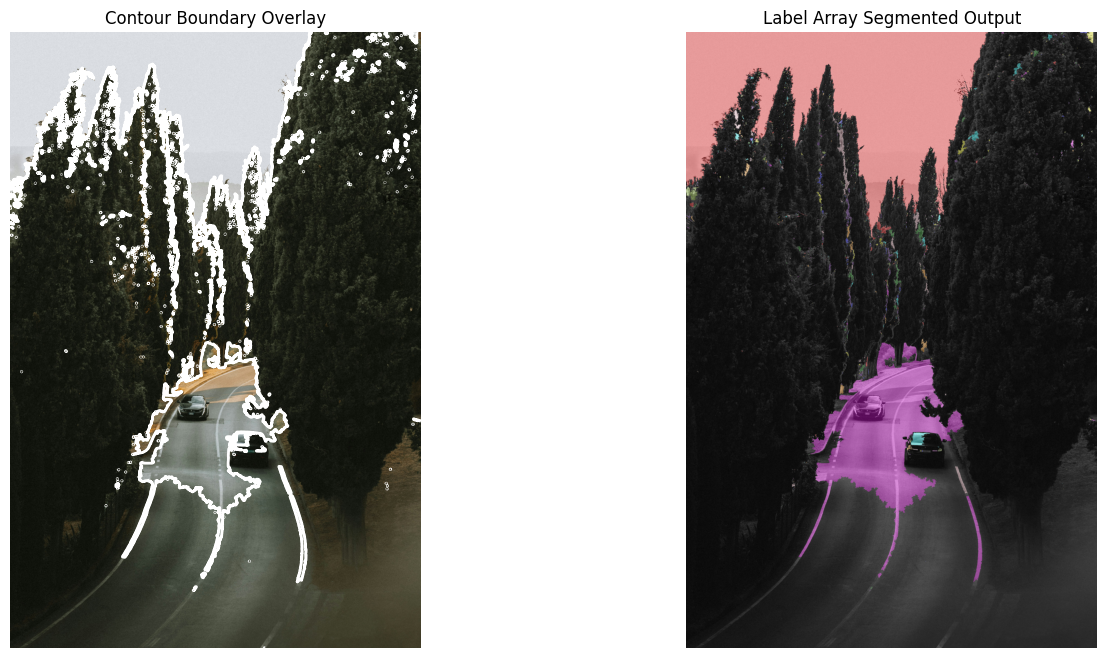

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import canny
from skimage import segmentation, morphology, filters
from skimage.color import rgb2gray, label2rgb
import scipy.ndimage as nd

plt.rcParams["figure.figsize"] = (12, 8)

if os.path.exists('sample_data/sample.jpg'):
    image_path = 'sample_data/sample.jpg'
elif os.path.exists('sample.jpg'):
    image_path = 'sample.jpg'
else:
    image_path = 'sample.jpg'

if os.path.exists(image_path):

    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img_gray = rgb2gray(image_rgb)

    edges = canny(img_gray)
    plt.figure()
    plt.imshow(edges, cmap='gray', interpolation='gaussian')
    plt.title('Canny detector')
    plt.axis('off')
    plt.show()

    fill_im = nd.binary_fill_holes(edges)
    plt.figure()
    plt.imshow(fill_im, cmap='gray')
    plt.title('Region Filling')
    plt.axis('off')
    plt.show()

    elevation_map = filters.sobel(img_gray)
    plt.figure()
    plt.imshow(elevation_map, cmap='jet')
    plt.title('Elevation Map')
    plt.axis('off')
    plt.show()

    markers = np.zeros(img_gray.shape, dtype=np.int32)
    markers[img_gray < 0.15] = 1
    markers[img_gray > 0.55] = 2
    plt.figure()
    plt.imshow(markers, cmap='Spectral')
    plt.title('Markers Map')
    plt.axis('off')
    plt.show()


    segments = segmentation.watershed(elevation_map, markers)
    plt.figure()
    plt.imshow(segments, cmap='jet')
    plt.title('Watershed Segmentation')
    plt.axis('off')
    plt.show()

    segments_filled = nd.binary_fill_holes(segments - 1)
    label_objects, _ = nd.label(segments_filled)

    image_label_overlay = label2rgb(label_objects, image=img_gray)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    ax1.imshow(image_rgb)
    ax1.contour(segments_filled, [0.5], linewidths=2.0, colors='w')
    ax1.set_title('Contour Boundary Overlay')
    ax1.axis('off')

    ax2.imshow(image_label_overlay)
    ax2.set_title('Label Array Segmented Output')
    ax2.axis('off')

    plt.show()
else:
    print(f"Error: Could not find '{image_path}'. Please verify it is in your sidebar.")